In [1]:
import os

def get_matching_files(directory, pattern):
    """
    Returns a list of file paths in 'directory' whose names contain 'pattern'.
    """
    return [
        os.path.join(directory, fname)
        for fname in os.listdir(directory)
        if pattern in fname
    ]

In [2]:
# fetch log files for evaluation
import re
import polars as pl

# use a looser matcher so files like:
#  - dt_rtg03_test_episode_02_logs.parquet
#  - dt_test_episode_02_rtg03_logs.parquet
# are both returned
matching_files = get_matching_files("../data", "test_episode_02")

# capture algorithm at start, trailing _logs (allow optional .parquet)
pat = re.compile(r"^(?P<algo>[A-Za-z0-9]+).*?_logs(?:\.parquet)?$", re.IGNORECASE)
# find _rtgNN anywhere in the name
rtg_search_re = re.compile(r"_rtg(?P<rtg>\d+)", re.IGNORECASE)

test_logs: dict[str, pl.DataFrame] = {}
skipped = []

for file_path in matching_files:
    fname = os.path.basename(file_path)
    m = pat.match(fname)
    if not m:
        print(f"Skipping unrecognized filename: {fname}")
        skipped.append(fname)
        continue

    algo = m.group("algo")
    rtg_m = rtg_search_re.search(fname)
    rtg = rtg_m.group("rtg") if rtg_m else None
    label = f"{algo}_rtg{rtg}" if rtg else algo

    # try to read parquet; if unreadable or empty, register empty DF so label exists
    try:
        if os.path.getsize(file_path) == 0:
            df = pl.DataFrame()
            print(f"Warning: zero-byte file -> empty DF for {label}: {fname}")
        else:
            df = pl.read_parquet(file_path)
    except Exception as e:
        print(f"Failed to read {fname}: {e} -> registering empty DF for {label}")
        df = pl.DataFrame()

    # ensure episode_id exists for non-empty frames
    if not df.is_empty() and "episode_id" not in df.columns:
        df = df.with_columns(pl.lit(0).alias("episode_id"))

    test_logs[label] = df
    print(f"Registered: {fname} -> label='{label}', rows={len(df)}")

print("Final labels:", list(test_logs.keys()))
print("Skipped files:", skipped)

Registered: sdp_test_episode_02_logs.parquet -> label='sdp', rows=962779
Registered: ddpg_test_episode_02_logs.parquet -> label='ddpg', rows=945262
Registered: dt_rtg100_test_episode_02_logs.parquet -> label='dt_rtg100', rows=962779
Registered: sac_test_episode_02_logs.parquet -> label='sac', rows=808946
Registered: dt_rtg03_test_episode_02_logs.parquet -> label='dt_rtg03', rows=945262
Registered: td3_test_episode_02_logs.parquet -> label='td3', rows=945262
Registered: mrdp_test_episode_02_logs.parquet -> label='mrdp', rows=963025
Registered: dt_rtg10_test_episode_02_logs.parquet -> label='dt_rtg10', rows=945262
Registered: a2c_test_episode_02_logs.parquet -> label='a2c', rows=3684914
Registered: ppo_test_episode_02_logs.parquet -> label='ppo', rows=674616
Registered: rule_test_episode_02_logs.parquet -> label='rule', rows=889581
Registered: dt_rtg30_test_episode_02_logs.parquet -> label='dt_rtg30', rows=962779
Final labels: ['sdp', 'ddpg', 'dt_rtg100', 'sac', 'dt_rtg03', 'td3', 'mrdp'

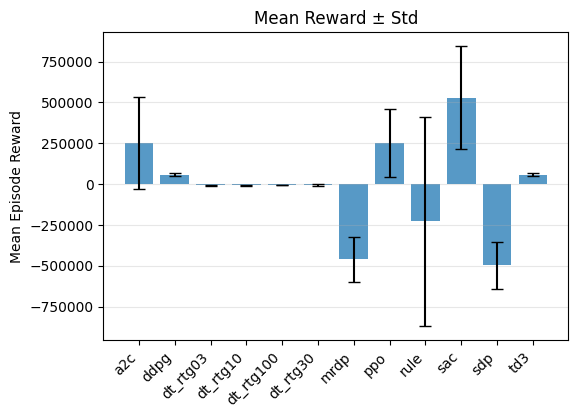

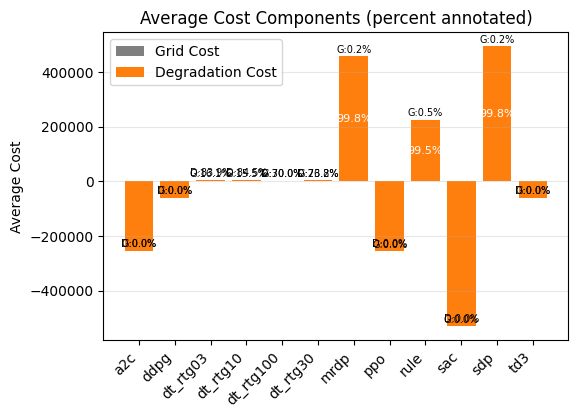

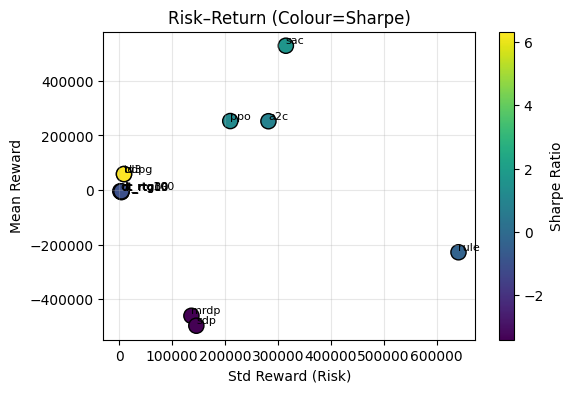

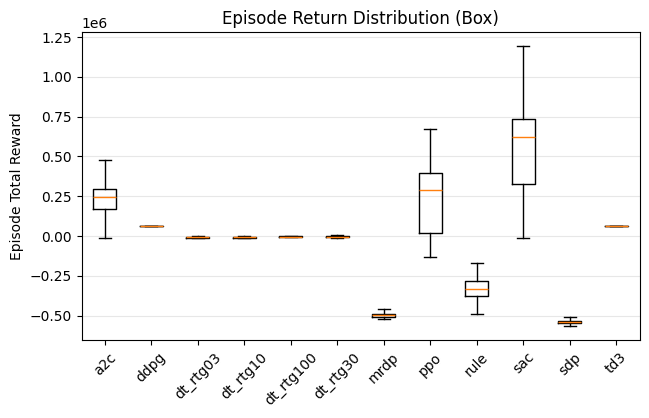

shape: (12, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ mean_rewa ┆ median_re ┆ std_rewar ┆ pct_5_rew ┆ … ┆ avg_grid_ ┆ avg_deg_c ┆ avg_opera ┆ experime │
│ rd        ┆ ward      ┆ d         ┆ ard       ┆   ┆ revenue   ┆ ost       ┆ tional_co ┆ nt       │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ st        ┆ ---      │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ ---       ┆ str      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ f64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 252172.79 ┆ 242495.13 ┆ 282272.52 ┆ 35435.331 ┆ … ┆ 30.264404 ┆ -254911.4 ┆ -253816.1 ┆ a2c      │
│ 4582      ┆ 1716      ┆ 9707      ┆ 688       ┆   ┆           ┆ 59864     ┆ 9459      ┆          │
│ 58749.194 ┆ 60956.928 ┆ 9291.1821 ┆ 52167.254 ┆ … ┆ 13.32293  ┆ -60958.95

In [ ]:
from helper import evaluate_experiments
# Split into a list of DataFrames, one per episode
all_logs = {
    label: [df.filter(pl.col("episode_id") == eid) for eid in df["episode_id"].unique()]
    for label, df in test_logs.items()
}

# evaluate experiments outcomes
metrics = evaluate_experiments(all_logs, target_return=0.0, save_dir="./eval_results")
print(metrics)

In [4]:
for algo, logs in all_logs.items():
    print(f"{algo}: {len(logs)} episodes")

sdp: 60 episodes
ddpg: 60 episodes
dt_rtg100: 60 episodes
sac: 60 episodes
dt_rtg03: 60 episodes
td3: 60 episodes
mrdp: 60 episodes
dt_rtg10: 60 episodes
a2c: 240 episodes
ppo: 60 episodes
rule: 60 episodes
dt_rtg30: 60 episodes


In [ ]:
from typing import Any
from helper import AlgorithmActionComparator, ActionComparisonConfig
def compare_action_pairwise_to_reference(
    logs_dict: dict[str, list[pl.DataFrame]],
    reference: str,
    **kwargs: Any,
) -> dict[str, Any]:
    """
    Run pairwise comparisons of each algorithm vs a reference algorithm.
    
    kwargs are forwarded to ActionComparisonConfig (e.g., bins, time_periods, etc.).
    Returns a dict: algo_name -> ActionComparisonResult or metrics dict.
    """
    comparator = AlgorithmActionComparator(action_logs=logs_dict)
    results: dict[str, Any] = {}
    for algo in logs_dict:
        if algo == reference:
            continue
        sub_logs = {reference: logs_dict[reference], algo: logs_dict[algo]}
        cfg = ActionComparisonConfig(reference=reference, **kwargs)
        result = comparator.compare(logs_dict=sub_logs, config=cfg)
        results[algo] = result
    return results


In [ ]:
steps_per_hour = int(1 / 0.5)  # number of steps per hour given a 30-min step duration (2)

def time_to_step(hour: int, minute: int = 0, second: int = 0, steps_per_hour_: int | None = None) -> int:
    """
    Convert a time-of-day (hour, minute, second) into a 0-indexed step mark for that day,
    using steps_per_hour (defaults to `steps_per_hour` defined above).
    Returns the floor of the step (i.e., which step interval that timestamp falls into).
    """
    sp = steps_per_hour_ or steps_per_hour
    total_seconds = hour * 3600 + minute * 60 + second
    seconds_per_step = 3600 / sp
    return int(total_seconds // seconds_per_step)

# time periods to compare in steps
# first 2 days, 2 days after 4th week, 2 days after 4th month, 2 days at 11th month (assuming 30-min per step, 48 steps/day)
first_step = 0
fourth_week = 4 * 7 * 48  # 4th week
fourth_month = 4 * 30 * 48  # 4th month
eleventh_month = 11 * 30 * 48  # 11th month
two_day_steps = 2 * 48

# morning period markers
five_am_mark = time_to_step(5, 0)   # 05:00
ten_am_mark = time_to_step(10, 0)   # 10:00

# mid-day marker
three_pm_mark = time_to_step(15, 0)  # 15:00

# evening marker
nine_pm_mark = time_to_step(21, 0)   # 21:00

# Example: create named time windows (start_step, end_step) you can pass to the comparator
time_periods = {
    "first_2_days": (first_step, first_step + two_day_steps),
    "4th_week_2_days": (fourth_week, fourth_week + two_day_steps),
    "4th_month_2_days": (fourth_month, fourth_month + two_day_steps),
    "11th_month_2_days": (eleventh_month, eleventh_month + two_day_steps),
    "morning": (first_step + five_am_mark, first_step + ten_am_mark),
    "afternoon": (first_step + three_pm_mark, first_step + three_pm_mark + steps_per_hour),  # 1-hour window
    "evening": (first_step + nine_pm_mark, first_step + nine_pm_mark + steps_per_hour),     # 1-hour window
}

# pick 52nd episode if exists for all algorithms
episode_52 = {}
for algo, logs in all_logs.items():
    if len(logs) > 52:
        episode_52[algo] = logs[52]

# Wrap single-episode DataFrames into lists expected by the comparator
episode_single = {k: [v] for k, v in episode_52.items()}

# check if we have data for episode 52
if not episode_52:
    print("No data available for episode 52 across the algorithms.")

In [ ]:
# overall comparison for action stat
pairwise_results = compare_action_pairwise_to_reference(
    all_logs,
    reference="rule",
    time_periods=None,
    bins='auto',
    max_episodes=20, # only uses 20 episodes to compile the stat
    save_dir = './eval_output'
)

In [ ]:
# Create comparator and config, then run
comparator = AlgorithmActionComparator()
cfg = ActionComparisonConfig(time_periods=time_periods, return_figs=True)
result = comparator.compare(logs_dict=episode_single, config=cfg)

# Extract metrics and figures (the comparator returns an ActionComparisonResult when return_figs=True)
if hasattr(result, 'metrics'):
    metrics = result.metrics
    figs = result.figures
else:
    metrics = result
    figs = {}

# Display metrics and figures
print(metrics)
for fig in figs.values():
    plt.show(fig)

In [ ]:
from helper import AlgorithmActionComparator, TemporalAnalysisConfig
import matplotlib.pyplot as plt

# Use the same time_periods defined earlier and the episode_8964 mapping (algo -> DataFrame)
# episode_8964 maps algorithm -> single episode DataFrame; analyze_temporal expects dict[str, pl.DataFrame]

comparator = AlgorithmActionComparator()
cfg = TemporalAnalysisConfig(time_periods=time_periods, annotate_states=True, step_duration=0.5, reference=None, action_tolerance=0.01)

result = comparator.analyze_temporal(logs_dict=episode_52, config=cfg)
fig = result.figure
stats = result.stats

# Display stats and figure
print(stats)
# In notebooks, use display of Matplotlib figure
plt.show(fig)


In [ ]:
# Example: Evaluate rewards under different conditions for one algorithm
from helper import evaluate_by_conditions

# Define your conditions (functions that take obs and return True/False)
conditions = {
    "high_solar": lambda obs: obs[5] > 2.0,
    "peak_price": lambda obs: obs[7] > 0.2,
    "low_battery": lambda obs: obs[-2] < 0.3
}

# logs is a list of Polars DataFrames for one algorithm
results = evaluate_by_conditions(logs, conditions)
print(results)